# Clusterização de Trajetórias de Ciclones Tropicais com TRACLUS

## Dados HURDAT2: Oceano Atlântico (2004–2025)

---

# 1. Introdução

Este notebook implementa o **TRACLUS** (TRAjectory CLUStering) e o aplica a trajetórias de tempestades e furacões do Atlântico da base **HURDAT2** (NOAA/NHC). O algoritmo usa um framework de **partição-e-agrupamento**: cada trajetória é quebrada em segmentos de reta, e segmentos semelhantes — de tempestades diferentes ou de trechos diferentes da mesma tempestade — são agrupados por densidade, revelando **sub-trajetórias comuns** que passariam despercebidas ao comparar trajetórias inteiras.

**Dados:** `hurdat2_trajectories.csv` (posição, `wind_kt`, `pressure_mb` e status a cada 6h, Atlântico 2004–2025).

In [1]:
# Importações utilizadas

# Bibliotecas
import json
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy import stats
from sklearn.metrics import silhouette_samples, silhouette_score

# Módulo TRACLUS
from traclus_core import (
    RAIO_TERRA_KM, EPSILON, NAO_CLASSIFICADO, RUIDO,
    latlon_para_xy, xy_para_latlon, adicionar_mapa_base,
    comprimento, componentes_distancia, distancia_segmentos,
    custo_L, mdl_com_particao, mdl_sem_particao, particionar_trajetoria,
    calcular_matriz_distancia, entropia_vizinhanca,
    clusterizar_segmentos, filtrar_cardinalidade_trajetorias, qmeasure,
    vetor_direcao_medio, gerar_trajetoria_representativa,
    construir_perfil_meteorologico,
)

## 1.1 Roteiro do notebook

| Bloco | Conteúdo |
|---|---|
| **1. Introdução** | Contexto e visão geral do TRACLUS |
| **2. Dados e pré-processamento** | HURDAT2, filtragem, EDA, conversão geográfica |
| **3. Fase 1 - Partição (MDL)** | Distâncias entre segmentos, custo MDL, algoritmo de partição |
| **4. Fase 2 - Agrupamento** | Distância entre segmentos, heurística de $\varepsilon$, clusterização, trajetória representativa |
| **5. Avaliação dos clusters** | Silhouette adaptado, QMeasure, cardinalidade, ruído |
| **6. Interpretação** | Intensidade, duração e regimes meteorológicos por cluster |

## 1.2 Visão geral do algoritmo TRACLUS

O TRACLUS tem **duas fases**:

**Fase 1 - Partição:** Cada trajetória é decomposta em segmentos de reta pelo princípio **MDL**, equilibrando *conciseness* (poucos segmentos) e *preciseness* (boa aproximação). Um algoritmo aproximado $O(n)$ escolhe pontos característicos sempre que particionar fica mais barato, em bits, do que manter a trajetória original.

**Fase 2 - Agrupamento:** Todos os segmentos formam um conjunto único $\mathcal{D}$, clusterizado por densidade com uma distância composta pelas componentes perpendicular ($d_\perp$), paralela ($d_\parallel$) e angular ($d_\theta$). Clusters válidos (cardinalidade mínima de trajetórias) recebem uma trajetória representativa via varredura (*sweep line*).

---
# 2. Dados e Pré-processamento

A base **HURDAT2** (NOAA/NHC) registra posição e intensidade de sistemas tropicais do Atlântico a cada 6h desde 1851. O arquivo `hurdat2_trajectories.csv` cobre 2004-2025, com `storm_id`, `storm_name`, data/hora, `status`, `latitude`/`longitude`, `wind_kt` e `pressure_mb`.

Nesta seção: carregamos e exploramos os dados brutos, aplicamos os filtros do estudo (status `TS`/`HU`, duração mínima), fazemos uma análise exploratória e convertemos lat/lon para um plano cartesiano em km.

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 6)

CAMINHO_DADOS = "dataset/hurdat2_trajectories.csv"
ESTADO_ALEATORIO = 123

pd.set_option("display.max_columns", None)

## 2.1 Carregamento e exploração inicial dos dados

In [3]:
df_bruto = pd.read_csv(CAMINHO_DADOS, parse_dates=["datetime"])

print(f"Total de registros (observações de 6h):   {len(df_bruto):,}")
print(f"Total de sistemas (storm_id) distintos:   {df_bruto['storm_id'].nunique()}")
print(f"Período coberto:                          {df_bruto['year'].min()}–{df_bruto['year'].max()}")

df_bruto.head()

Total de registros (observações de 6h):   11,885
Total de sistemas (storm_id) distintos:   388
Período coberto:                          2004–2025


,storm_id,storm_name,datetime,year,month,day,hour,minute,record_id,status,latitude,longitude,wind_kt,pressure_mb
0,AL012004,ALEX,2004-07-31 18:00:00,2004,7,31,18,0,NaN,TD,30.3,-78.3,25,1010
1,AL012004,ALEX,2004-08-01 00:00:00,2004,8,1,0,0,NaN,TD,31.0,-78.8,25,1009
2,AL012004,ALEX,2004-08-01 06:00:00,2004,8,1,6,0,NaN,TD,31.5,-79.0,25,1009
3,AL012004,ALEX,2004-08-01 12:00:00,2004,8,1,12,0,NaN,TD,31.6,-79.1,30,1009
4,AL012004,ALEX,2004-08-01 18:00:00,2004,8,1,18,0,NaN,TS,31.6,-79.2,35,1009


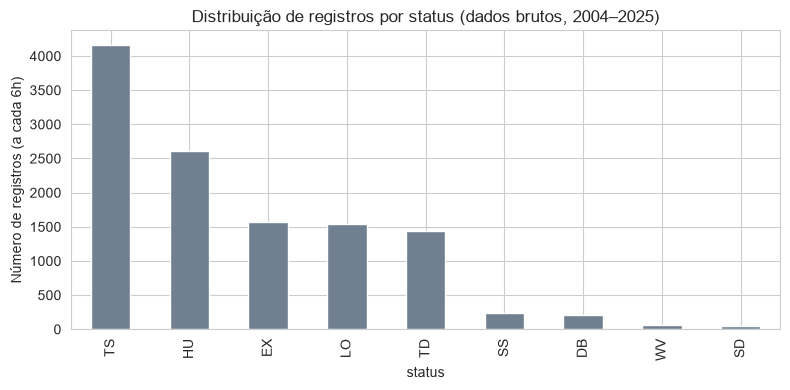

status
TS    4166
HU    2611
EX    1576
LO    1539
TD    1443
SS     233
DB     208
WV      68
SD      41
Name: count, dtype: int64

In [4]:
contagem_status = df_bruto["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
contagem_status.plot(kind="bar", ax=ax, color="slategray")
ax.set_title("Distribuição de registros por status (dados brutos, 2004–2025)")
ax.set_xlabel("status")
ax.set_ylabel("Número de registros (a cada 6h)")
plt.tight_layout()
plt.show()

contagem_status

**Códigos de `status` no HURDAT2:** `TD` (depressão tropical), `TS` (tempestade tropical), `HU` (furacão), `EX` (extratropical), `LO` (baixa remanescente), `SS`/`SD` (subtropical), `DB`/`WV` (perturbação/onda, pré-formação).

## 2.2 Critérios de filtragem

1. **Apenas `TS`/`HU`**: foco no comportamento de sistemas tropicais desenvolvidos, excluindo formação, dissipação e sistemas subtropicais.

2. **Duração mínima de 3 dias (12 observações a 6h)**: trajetórias mais curtas dão poucos pontos para uma partição MDL útil e tendem a virar ruído.

A filtragem é aplicada primeiro aos registros `TS`/`HU` e depois à contagem por sistema. É mantido apenas os trechos desenvolvidos de cada tempestade, não a trajetória inteira.

In [6]:
PONTOS_MINIMOS = 12
STATUS_VALIDOS = ["TS", "HU"]

# Mmanter apenas registros TS/HU
dados = df_bruto[df_bruto["status"].isin(STATUS_VALIDOS)].copy()

# Manter apenas sistemas com >= PONTOS_MINIMOS registros TS/HU
contagem_pontos = dados.groupby("storm_id").size()
tempestades_validas = contagem_pontos[contagem_pontos >= PONTOS_MINIMOS].index
dados = dados[dados["storm_id"].isin(tempestades_validas)].copy()

dados = dados.sort_values(["storm_id", "datetime"]).reset_index(drop=True)

print(f"Sistemas antes da filtragem:  {df_bruto['storm_id'].nunique()}")
print(f"Sistemas após filtragem:      {dados['storm_id'].nunique()}")
print(f"Registros antes da filtragem: {len(df_bruto):,}")
print(f"Registros após filtragem:     {len(dados):,}  "
      f"({len(dados) / len(df_bruto):.1%} do total)")

Sistemas antes da filtragem:  388
Sistemas após filtragem:      215
Registros antes da filtragem: 11,885
Registros após filtragem:     5,882  (49.5% do total)


In [7]:
# Tabela-resumo por tempestade
resumo_tempestades = dados.groupby("storm_id").agg(
    nome_tempestade=("storm_name", "first"),
    ano=("year", "first"),
    n_pontos=("latitude", "size"),
    vento_max=("wind_kt", "max"),
    vento_medio=("wind_kt", "mean"),
    pressao_min=("pressure_mb", "min"),
).reset_index()

resumo_tempestades["duracao_h"] = (resumo_tempestades["n_pontos"] - 1) * 6
resumo_tempestades["duracao_dias"] = resumo_tempestades["duracao_h"] / 24

print(f"Trajetórias finais: {len(resumo_tempestades)}")
resumo_tempestades.describe()[["n_pontos", "vento_max", "duracao_dias"]].round(2)

Trajetórias finais: 215


,n_pontos,vento_max,duracao_dias
count,215.00,215.00,215.00
mean,27.36,88.51,6.59
std,13.96,32.08,3.49
min,12.00,40.00,2.75
25%,16.00,60.00,3.75
50%,23.00,80.00,5.50
75%,36.50,112.50,8.88
max,83.00,165.00,20.50


## 2.3 Análise exploratória dos dados filtrados

Com as 215 trajetórias filtradas (5.882 pontos), examinamos três dimensões antes da etapa geométrica: distribuição de duração, de intensidade (`wind_kt`) e distribuição temporal (tempestades por ano).

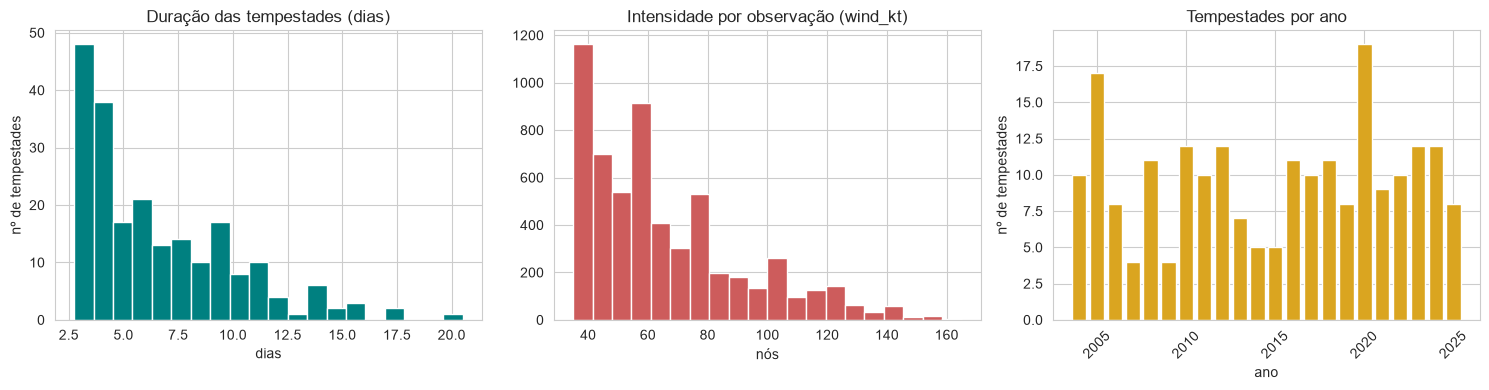

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(resumo_tempestades["duracao_dias"], bins=20, color="teal", edgecolor="white")
axes[0].set_title("Duração das tempestades (dias)")
axes[0].set_xlabel("dias")
axes[0].set_ylabel("nº de tempestades")

axes[1].hist(dados["wind_kt"], bins=20, color="indianred", edgecolor="white")
axes[1].set_title("Intensidade por observação (wind_kt)")
axes[1].set_xlabel("nós")

tempestades_por_ano = resumo_tempestades["ano"].value_counts().sort_index()
axes[2].bar(tempestades_por_ano.index, tempestades_por_ano.values, color="goldenrod")
axes[2].set_title("Tempestades por ano")
axes[2].set_xlabel("ano")
axes[2].set_ylabel("nº de tempestades")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

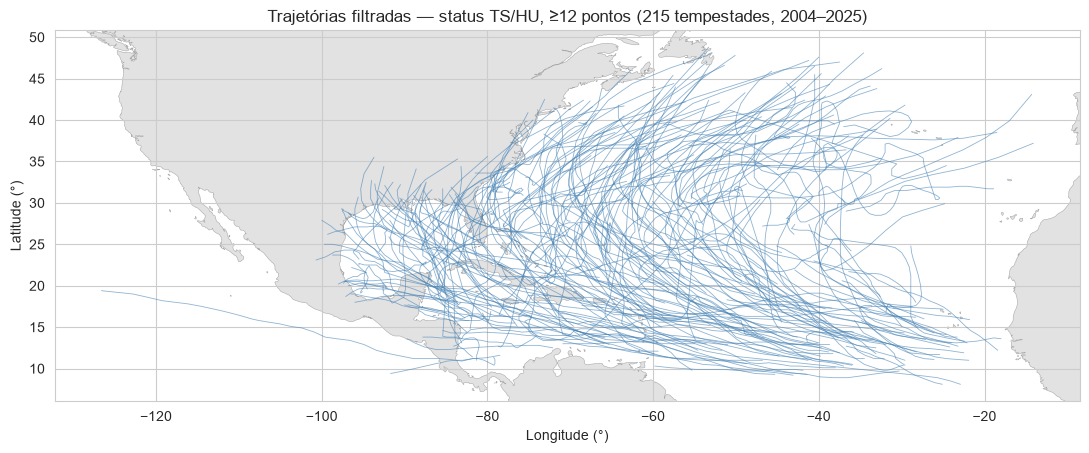

In [9]:
CAMINHO_MAPA_BASE = "dataset/mapa_base_atlantico.geojson"
# Carrega o arquivo geojson para projetar o mapa

fig, ax = plt.subplots(figsize=(11, 6))

for id_tempestade, grupo in dados.groupby("storm_id"):
    ax.plot(grupo["longitude"], grupo["latitude"], lw=0.6, alpha=0.6, color="steelblue", zorder=2)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Trajetórias filtradas — status TS/HU, ≥{PONTOS_MINIMOS} pontos "
              f"({resumo_tempestades.shape[0]} tempestades, 2004–2025)")
ax.set_aspect("equal")
adicionar_mapa_base(ax)
plt.tight_layout()
plt.show()

## 2.4 Conversão de coordenadas geográficas para cartesianas

As distâncias do TRACLUS pressupõem um espaço **euclidiano plano**, mas 1° de longitude equivale a $\approx 111\cos(\text{lat})$ km enquanto 1° de latitude é sempre $\approx 111$ km. Aplicar as fórmulas direto sobre graus distorceria ângulos e distâncias.

**Solução:** projeção equirretangular com correção de cosseno, usando o centróide global do conjunto como referência $(\text{lat}_{ref}, \text{lon}_{ref})$ com $R \approx 6371$ km:

$$x = R \cdot (\text{lon} - \text{lon}_{ref}) \cdot \cos(\text{lat}_{ref}) \cdot \frac{\pi}{180}, \qquad y = R \cdot (\text{lat} - \text{lat}_{ref}) \cdot \frac{\pi}{180}$$

Ponto de referência: lat_ref = 24.16°, lon_ref = -62.87°
Extensão em x: [-6,466, 4,948] km
Extensão em y: [-1,786, 2,739] km


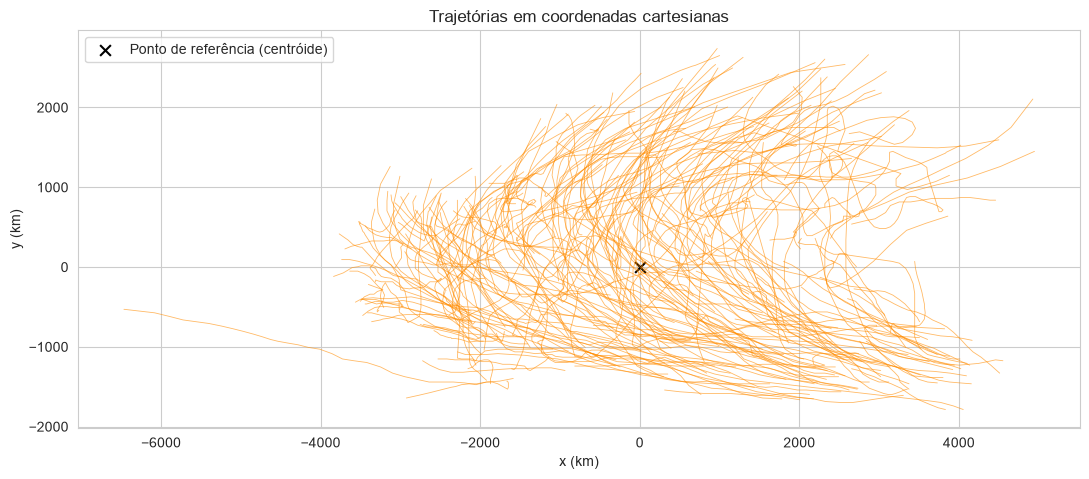

In [10]:
LAT_REF = dados["latitude"].mean()
LON_REF = dados["longitude"].mean()

dados["x_km"], dados["y_km"] = latlon_para_xy(
    dados["latitude"], dados["longitude"], LAT_REF, LON_REF
) # Transforma latitude e longitude em coordenadas (x, y) em km

print(f"Ponto de referência: lat_ref = {LAT_REF:.2f}°, lon_ref = {LON_REF:.2f}°")
print(f"Extensão em x: [{dados['x_km'].min():,.0f}, {dados['x_km'].max():,.0f}] km")
print(f"Extensão em y: [{dados['y_km'].min():,.0f}, {dados['y_km'].max():,.0f}] km")

dados[["storm_id", "latitude", "longitude", "x_km", "y_km"]].head()

# Plota o gráfico das trajetórias + centróide
fig, ax = plt.subplots(figsize=(11, 6))

for id_tempestade, grupo in dados.groupby("storm_id"):
    ax.plot(grupo["x_km"], grupo["y_km"], lw=0.6, alpha=0.6, color="darkorange")

ax.scatter([0], [0], color="black", marker="x", s=60, label="Ponto de referência (centróide)")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Trajetórias em coordenadas cartesianas")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()